# **Forecasting a multi-variate time series**

In [3]:
import os
#from google.colab import drive
import urllib.request

developerMode=False

if developerMode:
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/Colab Notebooks/Sofie')
else:
    os.makedirs('./data', exist_ok=True)
    FILE_PATH = "data/tsynth2.parquet"
    if not os.path.exists(FILE_PATH):
      url = "https://www.dropbox.com/scl/fi/quwa6mu346dcdu33fuy5q/tsynth2.parquet?rlkey=wcbx1oo76kzx9sjk9xo6xagqs&dl=1"
      urllib.request.urlretrieve(url, FILE_PATH)
      print("✅ Downloaded", FILE_PATH)
    else:
      print(FILE_PATH, "Already exists")

    FILE_PATH= "data/tsynth.parquet"
    if not os.path.exists(FILE_PATH):
      url = "https://www.dropbox.com/scl/fi/pfuvhkud6yzxind2p4jxr/tsynth.parquet?rlkey=tz4lgrmuj5llio5d4rxwt5xis&dl=1"
      urllib.request.urlretrieve(url, FILE_PATH)
      print("✅ Downloaded", FILE_PATH)
    else:
      print(FILE_PATH, "Already exists")


    FILE_PATH= "data/air_quality.parquet"
    if not os.path.exists(FILE_PATH):
      url = "https://www.dropbox.com/scl/fi/p9ubzua7d99oe4phbog4v/air_quality.parquet?rlkey=snbkyw80sx624f1325fflgky2&dl=1"
      urllib.request.urlretrieve(url, FILE_PATH)
      print("✅ Downloaded", FILE_PATH)
    else:
      print(FILE_PATH, "Already exists")


    FILE_PATH= "data/AWMD.parquet"
    if not os.path.exists(FILE_PATH):
      url = "https://www.dropbox.com/scl/fi/x9ddlib4re1194urh9vnd/AWMD.parquet?rlkey=tx0p172yt8hw72w9cghq8c9ee&dl=1"
      urllib.request.urlretrieve(url, FILE_PATH)
      print("✅ Downloaded", FILE_PATH)
    else:
      print(FILE_PATH, "Already exists")

    !ls


✅ Downloaded data/tsynth2.parquet
✅ Downloaded data/tsynth.parquet
✅ Downloaded data/air_quality.parquet
✅ Downloaded data/AWMD.parquet
ar.py                Forecasting.ipynb    seasonal.py
bench.temp.200.Rdata jena_climate.csv     ts_preproc.py
data                 logistic.py
direct.py            ma.py


## Imports

In [52]:
!pip install tabpfn-client

  DEPRECATION: Wheel filename 'password_strength-0.0.1_1-py2-none-any.whl' is not correctly normalised. Future versions of pip will raise the following error:
  Invalid wheel filename (invalid version): 'password_strength-0.0.1_1-py2-none-any'
  
   pip 25.3 will enforce this behaviour change. A possible replacement is to rename the wheel to use a correctly normalised name (this may require updating the version in the project metadata). Discussion can be found at https://github.com/pypa/pip/issues/12938
  DEPRECATION: Wheel filename 'password_strength-0.0.2_0-py2-none-any.whl' is not correctly normalised. Future versions of pip will raise the following error:
  Invalid wheel filename (invalid version): 'password_strength-0.0.2_0-py2-none-any'
  
   pip 25.3 will enforce this behaviour change. A possible replacement is to rename the wheel to use a correctly normalised name (this may require updating the version in the project metadata). Discussion can be found at https://github.com/pypa

In [7]:

import requests
import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import zipfile
import os
import copy
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
from statsmodels.tsa.api import VAR
import lightgbm as lgb
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

## Preprocessing functions

In [39]:
class TimeSeriesImputer(BaseEstimator, TransformerMixin):
    """
    Deterministic, index-preserving imputer.
    """

    def __init__(self, method="time"):
        self.method = method

    def fit(self, X, y=None):
        self._validate(X)
        return self

    def transform(self, X):
        self._validate(X)

        if self.method == "time":
            return X.interpolate(method="time", limit_direction="both")
        elif self.method == "ffill":
            return X.ffill().bfill()
        else:
            raise ValueError("Unknown imputation method")

    def _validate(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Input must be DataFrame")
        if not isinstance(X.index, pd.DatetimeIndex):
            raise TypeError("Index must be DatetimeIndex")
    def inverse_transform(self, X):
        return X


class ReversiblePipeline:
    def __init__(self, steps):
        """
        steps: list of (name, transformer)
        Each transformer must implement:
        - fit(X: pd.DataFrame)
        - transform(X: pd.DataFrame) -> pd.DataFrame
        - inverse_transform(X: pd.DataFrame) -> pd.DataFrame
        """
        self.steps = steps

    def fit(self, X: pd.DataFrame):
        X = X.copy()
        for _, step in self.steps:
            step.fit(X)
            X = step.transform(X)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        for _, step in self.steps:
            X = step.transform(X)
        return X

    def inverse_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        for _, step in reversed(self.steps):
            X = step.inverse_transform(X)
        return X

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        self.fit(X)
        return self.transform(X)

import numpy as np
import pandas as pd

class InvertibleSTLTransform:
    def __init__(self, period=None, detrend_only=False, max_lag=100):
        """
        period: int or None (auto-detect if None)
        max_lag: search range for period detection
        """
        self.period = period
        self.detrend_only = detrend_only
        self.max_lag = max_lag

    def fit(self, X: pd.DataFrame):
        self.columns_ = X.columns
        self.index_ = X.index

        values = X.values
        T, d = values.shape

        # ---------- Time index ----------
        t = np.arange(T)
        A = np.vstack([t, np.ones(T)]).T

        # ---------- Fit linear trend ----------
        self.coef_ = np.zeros((d, 2))
        for j in range(d):
            self.coef_[j], *_ = np.linalg.lstsq(A, values[:, j], rcond=None)

        # ---------- DETREND ----------
        trend = self._trend_at(t)
        detrended = values - trend

        # ---------- Auto period detection ----------
        if self.period is None:
            self.period = self._detect_period(detrended)
            print(f"[STL] Detected period: {self.period}")

        # ---------- Seasonal component ----------
        if not self.detrend_only:
            seasonal = np.zeros((self.period, d))
            for p in range(self.period):
                seasonal[p] = detrended[p::self.period].mean(axis=0)

            self.seasonal_pattern_ = seasonal

        self.n_train_ = T
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        values = X.values
        T = len(values)

        t = self._time_index(T)
        trend = self._trend_at(t)

        if self.detrend_only:
            out = values - trend
        else:
            seasonal = self._extend_seasonal(T)
            out = values - trend - seasonal

        return pd.DataFrame(out, index=X.index, columns=self.columns_)

    def inverse_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        values = X.values
        T = len(values)

        t = self._time_index(T)
        trend = self._trend_at(t)

        if self.detrend_only:
            out = values + trend
        else:
            seasonal = self._extend_seasonal(T)
            out = values + trend + seasonal

        return pd.DataFrame(out, index=X.index, columns=self.columns_)

    # ---------- helpers ----------

    def _detect_period(self, detrended):
        """
        Detect dominant period using autocorrelation.
        """
        T = detrended.shape[0]
        max_lag = min(self.max_lag, T // 2)

        # aggregate across variables (robust)
        signal = detrended.mean(axis=1)

        # normalize
        signal = signal - signal.mean()

        acf = np.correlate(signal, signal, mode="full")
        acf = acf[acf.size // 2:]
        acf = acf[:max_lag]

        # avoid lag 0
        acf[0] = 0

        period = np.argmax(acf)

        # fallback safety
        if period <= 1:
            period = 2

        return period

    def _time_index(self, T):
        return np.arange(T) + (self.n_train_ - T)

    def _trend_at(self, t):
        a = self.coef_[:, 0]
        b = self.coef_[:, 1]
        return np.outer(t, a) + b

    def _extend_seasonal(self, T):
        idx = np.arange(T) % self.period
        return self.seasonal_pattern_[idx]





class InvertibleNormalizer:
    def __init__(self, method="zscore", eps=1e-8):
        """
        method: "zscore" (standardization) or "minmax"
        eps: small value to avoid division by zero
        """
        self.method = method
        self.eps = eps

    def fit(self, X: pd.DataFrame):
        self.columns_ = X.columns

        values = X.values.astype(float)

        if self.method == "zscore":
            self.mean_ = values.mean(axis=0)
            self.std_ = values.std(axis=0)
        elif self.method == "minmax":
            self.min_ = values.min(axis=0)
            self.max_ = values.max(axis=0)
        else:
            raise ValueError("Unknown method")

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        values = X.values.astype(float)

        if self.method == "zscore":
            out = (values - self.mean_) / (self.std_ + self.eps)
        else:  # minmax
            out = (values - self.min_) / (self.max_ - self.min_ + self.eps)

        return pd.DataFrame(out, index=X.index, columns=self.columns_)

    def inverse_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        values = X.values.astype(float)

        if self.method == "zscore":
            out = values * (self.std_ + self.eps) + self.mean_
        else:  # minmax
            out = values * (self.max_ - self.min_ + self.eps) + self.min_

        return pd.DataFrame(out, index=X.index, columns=self.columns_)

In [41]:
##
## check consistency reversible pipeline

if False:
  pipeline = ReversiblePipeline(steps=[
      ("impute", TimeSeriesImputer(method="time")),
      ("stl", InvertibleSTLTransform(period=4, detrend_only=False)),
      ("norm",InvertibleNormalizer(method="zscore"))
  ])


  dft=pipeline.fit_transform(df)
  dfb=pipeline.inverse_transform(dft.iloc[300:,:])
  df.iloc[300:,:]-dfb.iloc[:,:]

## Forecasting functions

In [44]:
def rmse(y, yhat):
    return np.mean(np.sqrt(np.mean((y - yhat)**2,axis=0))) ## columnwise NMSE

def nmse(y, yhat):
    eps=1e-8
    return np.mean(np.mean(((y - yhat)**2),axis=0)/(np.var(y,axis=0)+eps)) ## columnwise NMSE

In [54]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token("tabpfn_sk_q_f2jjMTg9Sh65javDnxF80CVjixdrH_mOsAcvNW9Tg")


In [107]:

# ============================================================
# 1. Dynamic Factor Model (DFM)
# ============================================================
class DFM(nn.Module):
    def __init__(self, input_dim, factor_dim, hidden_dim, H):
        super().__init__()
        self.H = H

        self.encoder = nn.Linear(input_dim, factor_dim)
        self.rnn = nn.GRU(factor_dim, hidden_dim, batch_first=True)
        self.factor_to_factor = nn.Linear(hidden_dim, factor_dim)
        self.decoder = nn.Linear(factor_dim, input_dim)

    def forward(self, x):
        f = self.encoder(x)
        _, h = self.rnn(f)
        f_prev = f[:, -1, :]

        preds = []
        for _ in range(self.H):
            out, h = self.rnn(f_prev.unsqueeze(1), h)
            f_next = self.factor_to_factor(out.squeeze(1))
            preds.append(f_next)
            f_prev = f_next

        F = torch.stack(preds, dim=1)
        return self.decoder(F)




class TransformerDFM(nn.Module):
    def __init__(
        self,
        input_dim,
        factor_dim,
        model_dim,
        H,
        num_heads=2,
        num_layers=2,
        dropout=0.0
    ):
        super().__init__()
        self.H = H

        # 1. Encoder: observations → latent factors
        self.encoder = nn.Linear(input_dim, factor_dim)

        # 2. Project factors to Transformer dimension
        self.factor_to_model = nn.Linear(factor_dim, model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # 3. Predict H future factors from final state
        self.model_to_factors = nn.Linear(model_dim, H * factor_dim)

        # 4. Decode factors → observations
        self.decoder = nn.Linear(factor_dim, input_dim)

    def forward(self, x):
        """
        x: (batch, T, input_dim)
        returns: (batch, H, input_dim)
        """

        # Encode observations
        f = self.encoder(x)                     # (B, T, factor_dim)
        z = self.factor_to_model(f)              # (B, T, model_dim)

        # Transformer over time
        h = self.transformer(z)                  # (B, T, model_dim)
        h_last = h[:, -1]                        # (B, model_dim)

        # Predict future latent factors
        F = self.model_to_factors(h_last)        # (B, H * factor_dim)
        F = F.view(-1, self.H, f.size(-1))       # (B, H, factor_dim)

        # Decode
        return self.decoder(F)


# ============================================================
# 2. dfm_forecast(): Training + Validation + Forecasting
# ============================================================
def dfm_forecast(
    ts_train,
    H=12,
    window=48,
    factors=3,
    hidden=64,
    epochs=30,
    lr=1e-3,
    val_split=0.2,
    plot_training=False,
    transformer=False,
    verbose=False
):
    """
    Train a Dynamic Factor Model only on ts_train and return H-step forecast.
    """

    # ---------- Normalize ----------
    mu = ts_train.mean(axis=0)
    sd = ts_train.std(axis=0) + 1e-8
    ts_n = (ts_train - mu) / sd

    # ---------- Build windows ----------
    X, Y = [], []
    for t in range(len(ts_n) - window - H):
        X.append(ts_n[t:t+window])
        Y.append(ts_n[t+window:t+window+H])

    X = np.array(X)
    Y = np.array(Y)

    # ---------- Train/Val split ----------
    n = len(X)
    split = int((1 - val_split) * n)
    X_train, Y_train = X[:split], Y[:split]
    X_val,   Y_val   = X[split:], Y[split:]

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)
    X_val   = torch.tensor(X_val,   dtype=torch.float32)
    Y_val   = torch.tensor(Y_val,   dtype=torch.float32)

    # ---------- Model ----------

    if transformer:
        model = TransformerDFM(ts_train.shape[1], factors, hidden, H)
    else:
        model = DFM(ts_train.shape[1], factors, hidden, H)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []



    best_val_loss = float("inf")
    best_model_state = None



    for ep in range(epochs):

        # ------------------
        # Train
        # ------------------
        model.train()
        optimizer.zero_grad()

        pred = model(X_train)
        loss_train = loss_fn(pred, Y_train)

        loss_train.backward()
        optimizer.step()

        # ------------------
        # Validation
        # ------------------
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val)
            loss_val = loss_fn(pred_val, Y_val)

        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())

        # ------------------
        # Store best model
        # ------------------
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            best_model_state = copy.deepcopy(model.state_dict())

        # ------------------
        # Logging
        # ------------------
        if verbose and (ep % 5 == 0):
            print(
                f"Epoch {ep:03d} | "
                f"Train={loss_train.item():.4f} | "
                f"Val={loss_val.item():.4f}"
            )

    # ------------------
    # Restore best model
    # ------------------
    model.load_state_dict(best_model_state)
    if verbose:
        print(f"Best validation loss: {best_val_loss:.4f}")



    # ---------- Plot training curves ----------
    if plot_training:
        plt.figure(figsize=(10,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.title("Training & Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # ---------- Forecast the next H steps ----------
    last_window = ts_n[-window:]
    last_window = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        pred_norm = model(last_window).numpy()[0]

    return pred_norm * sd + mu






# ============================================================
# 4. Baselines
# ============================================================
def naive_last(ts_train, H):
    return np.tile(ts_train[-1], (H, 1))

def naive_mean(ts_train, H, window=48):
    m = ts_train[-window:].mean(axis=0)
    return np.tile(m, (H, 1))




params = {
    "objective": "regression",
    "learning_rate": 0.05,
    "max_depth": -1,
    "verbosity": -1,
}


import numpy as np
import tabpfn_client
from tabpfn_client import TabPFNClassifier, TabPFNRegressor, set_access_token


def tabpfn_direct_forecast(ts_train, H=12, window=48, device="cpu",
                            max_train_samples=None, verbose=False):
    """
    TabPFN baseline using DIRECT multi-step forecasting:
    - One TabPFN model per variable per horizon step.
    - Input: last `window` lag values for all variables (flattened).
    - Output: H-step forecast (H, N).

    TabPFN is a pretrained, in-context tabular foundation model: no
    hyperparameter tuning or gradient training is needed, `.fit()` just
    stores the context (support set) and `.predict()` performs in-context
    inference. Because inference cost grows with the number of training
    rows, `max_train_samples` optionally caps/subsamples the supervised
    dataset (TabPFN is designed for small/medium tabular problems).

    Parameters
    ----------
    ts_train : np.ndarray (T_train, N)
    H : int
        Forecast horizon.
    window : int
        Number of lags used as input.
    device : str
        'cpu' or 'cuda' (TabPFN benefits strongly from GPU).
    max_train_samples : int or None
        If set, randomly subsample the supervised dataset to at most this
        many rows before fitting each TabPFN model (recommended for large
        T_train, since TabPFN's context window is bounded in practice).
    verbose : bool

    Returns
    -------
    forecast : np.ndarray (H, N)
        H-step forecast in original space.
    """
    T, N = ts_train.shape
    X_list = []
    Y_list = [[] for _ in range(H)]  # Y_list[h][sample] = X_{t+h}

    # ---------- Build supervised dataset ----------
    for t in range(window, T - H):
        X_list.append(ts_train[t - window : t].flatten())  # flatten multivariate window
        for h in range(H):
            Y_list[h].append(ts_train[t + h])

    X = np.array(X_list)               # shape: (samples, window*N)
    Y = [np.array(y) for y in Y_list]  # list of H arrays: (samples, N)

    # ---------- Optional subsampling (TabPFN context-size practicality) ----------
    if max_train_samples is not None and X.shape[0] > max_train_samples:
        rng = np.random.default_rng(0)
        idx = rng.choice(X.shape[0], size=max_train_samples, replace=False)
        X_fit = X[idx]
        Y_fit = [y[idx] for y in Y]
        if verbose:
            print(f"Subsampled training set from {X.shape[0]} to {max_train_samples} rows")
    else:
        X_fit = X
        Y_fit = Y
    set_access_token("tabpfn_sk_q_f2jjMTg9Sh65javDnxF80CVjixdrH_mOsAcvNW9Tg")

    # ---------- Train H*N TabPFN models (direct strategy) ----------
    tabpfn_models = [
        [TabPFNRegressor() for _ in range(N)]
        for _ in range(H)
    ]

    for h in range(H):
        for var in range(N):
            tabpfn_models[h][var].fit(X_fit, Y_fit[h][:, var])
            if verbose:
                print(f"Fitted TabPFN for horizon {h+1}, variable {var+1}/{N}")

    # ---------- Forecast from last window ----------
    last_window = ts_train[-window:].flatten().reshape(1, -1)
    forecast = np.zeros((H, N))
    for h in range(H):
        for j in range(N):
            forecast[h, j] = tabpfn_models[h][j].predict(last_window)[0]

    return forecast

def gb_direct_forecast(ts_train, H=12, window=48, verbose=False):
    """
    Gradient Boosting baseline using DIRECT multi-step forecasting:
    - One model per variable per horizon step.
    - Input: last `window` lag values for all variables.
    - Output: H-step forecast (H, N).

    Parameters
    ----------
    ts_train : np.ndarray (T_train, N)
    H : int
        Forecast horizon.
    window : int
        Number of lags used as input.

    Returns
    -------
    forecast : np.ndarray (H, N)
        H-step forecast in original space.
    """

    T, N = ts_train.shape
    X_list = []
    Y_list = [[] for _ in range(H)]  # Y_list[h][sample] = X_{t+h}

    # ---------- Build supervised dataset ----------
    for t in range(window, T - H):
        X_list.append(ts_train[t - window : t].flatten())  # flatten multivariate window

        for h in range(H):
            Y_list[h].append(ts_train[t + h])

    X = np.array(X_list)                      # shape: (samples, window*N)
    Y = [np.array(y) for y in Y_list]         # list of H arrays: (samples, N)

    # ---------- Train H*N models (direct strategy) ----------
    #model =
    gb_models = [
        [lgb.LGBMRegressor(**params) for _ in range(N)]
        for _ in range(H)
    ]


    for h in range(H):
        for var in range(N):
            gb_models[h][var].fit(X, Y[h][:, var])
            if verbose:
                print(f"Trained GB for horizon {h+1}, variable {var+1}/{N}")

    # ---------- Forecast from last window ----------
    last_window = ts_train[-window:].flatten().reshape(1, -1)
    forecast = np.zeros((H, N))
    for h in range(H):
        for j in range(N):
            forecast[h, j] = gb_models[h][j].predict(last_window)[0]
    return forecast





def var_forecast(ts_train, H=12, window=48, verbose=False):
    """
    VAR multi-step forecaster (statsmodels-based).

    Parameters
    ----------
    ts_train : np.ndarray (T, N)
    H : int
        Forecast horizon
    window : int
        Number of lags (VAR order)

    Returns
    -------
    forecast : np.ndarray (H, N)
    """

    T, N = ts_train.shape

    # ---------- Fit VAR model ----------
    model = VAR(ts_train)

    # Fit with specified lag order
    results = model.fit(maxlags=window)

    if verbose:
        print(f"Fitted VAR with lag order: {results.k_ar}")

    # ---------- Prepare last window ----------
    lag_order = results.k_ar

    # VAR needs k_ar past observations
    last_values = ts_train[-lag_order:]

    # ---------- Forecast ----------
    forecast = results.forecast(y=last_values, steps=H)

    return forecast

## Loading file and preprocessing the time series

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)'],
      dtype='object')


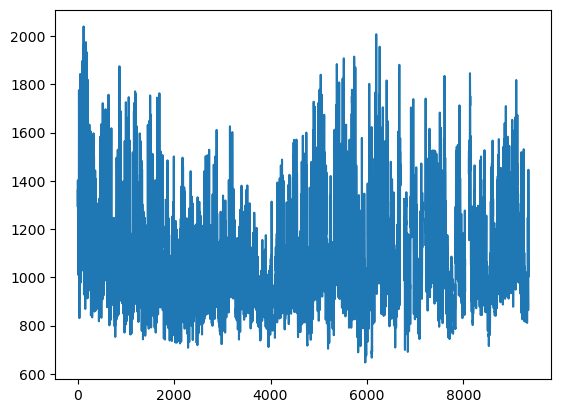

In [110]:



#df=pd.read_parquet("data/macro_monthly.parquet")
df=pd.read_parquet("data/AWMD.parquet")
df=pd.read_parquet("data/air_quality.parquet")
#df=pd.read_parquet("data/tsynth2.parquet")
names=df.columns
df.index = pd.to_datetime(df.index)

pipeline = ReversiblePipeline(steps=[
    ("impute", TimeSeriesImputer(method="time")),
    ("stl", InvertibleSTLTransform(period=None, detrend_only=False)),
    ("norm",InvertibleNormalizer(method="zscore"))
])


#tsAll = pipeline.fit_transform(df).to_numpy()


n=df.shape[1]
tsdf=df.iloc[:,:n]
ts=tsdf.to_numpy()
print(names[:n])
plt.plot(ts[:,1]);

In [112]:
tsdf.index = pd.to_datetime(tsdf.index)

(24, 6)


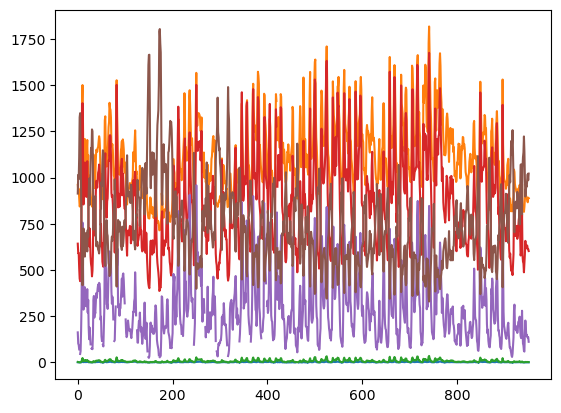

In [114]:
if ts.shape[0]>1000:
    ts=ts[-1000:,:]

H=24
starting_t=ts.shape[0]-2*H

ts_train = ts[:starting_t,:]
true_future = ts[starting_t:(starting_t+H),:]

plt.plot(ts_train)
print(true_future.shape)

## Embedding

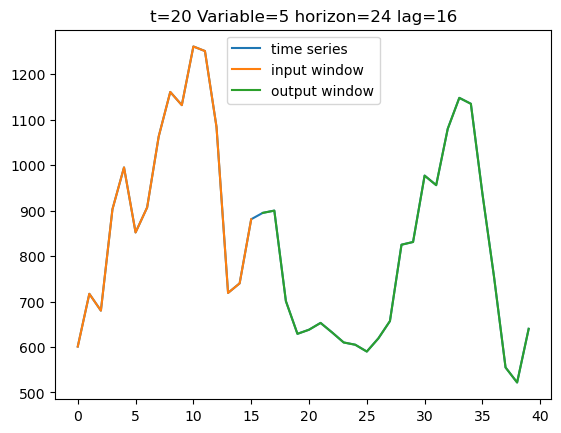

In [117]:


window=16
# ---------- Build windows ----------
X, Y = [], []
for t in range(len(ts) - window - H):
    X.append(ts[t:t+window])
    Y.append(ts[t+window:t+window+H])

X = np.array(X)
Y = np.array(Y)


t=20
j=n-1
plt.plot(ts[t:window+H+t,j]+0.05,label='time series')
plt.plot(X[t,:,j],label='input window');
plt.plot(np.concatenate((X[t,:,j]*np.nan, Y[t,:,j])),label='output window');
tit="t="+str(t)+" Variable="+ str(j)+ " horizon="+ str(H)+ " lag="+ str(window)
plt.title(tit)
plt.legend();

## Multi-step ahead forecasting

 Predicting  6 steps forward at time t= 976 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 976 DFM           : 84.2126673045897
t= 976 DFMT          : 84.2126673045897
t= 976 GB-Direct     : 69.9277297565713
t= 976 Naive Last    : 81.2660458425917
t= 976 Naive Mean    : 103.74906668638343
t= 976 VAR    : 42.90021079453385

=== nMSE RESULTS ===
t= 976 DFM           : 2.9449543182718676
t= 976 DFMT          : 2.9449543182718676
t= 976 GB-Direct     : 1.5234610364204304
t= 976 Naive Last    : 2.43053350679034
t= 976 Naive Mean    : 3.8683481480712683
t= 976 VAR    : 0.6607512745185526


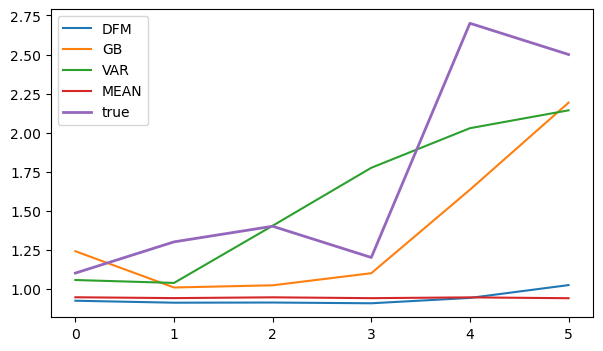

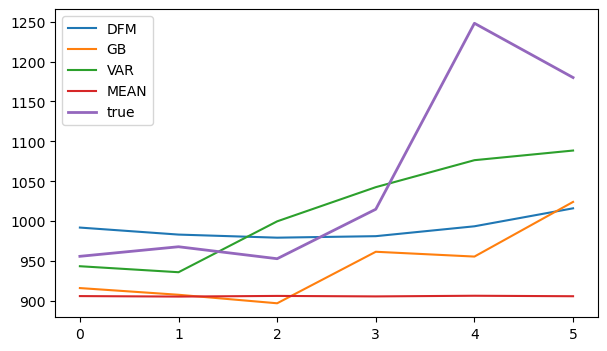

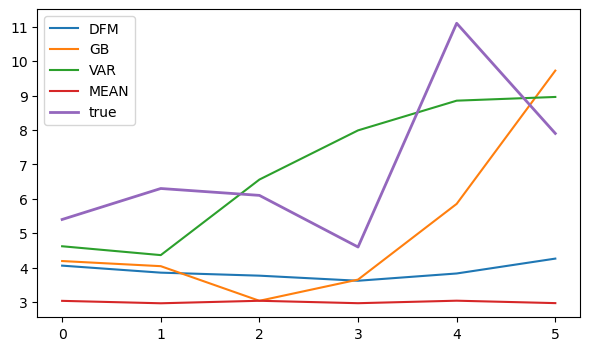

 Predicting  6 steps forward at time t= 977 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 977 DFM           : 75.4763589560755
t= 977 DFMT          : 75.4763589560755
t= 977 GB-Direct     : 64.22756841317093
t= 977 Naive Last    : 75.38084453369045
t= 977 Naive Mean    : 105.74651979430013
t= 977 VAR    : 43.61400160385293

=== nMSE RESULTS ===
t= 977 DFM           : 2.5410586411467504
t= 977 DFMT          : 2.5410586411467504
t= 977 GB-Direct     : 1.458945689947979
t= 977 Naive Last    : 2.1869260234303938
t= 977 Naive Mean    : 4.1450254160004345
t= 977 VAR    : 0.8809970353075623


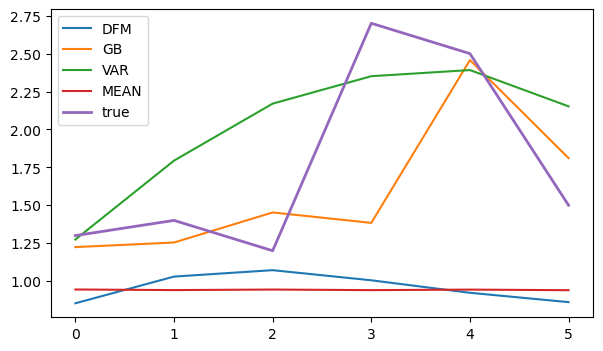

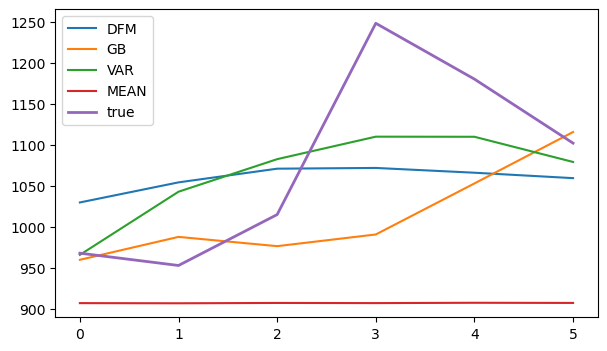

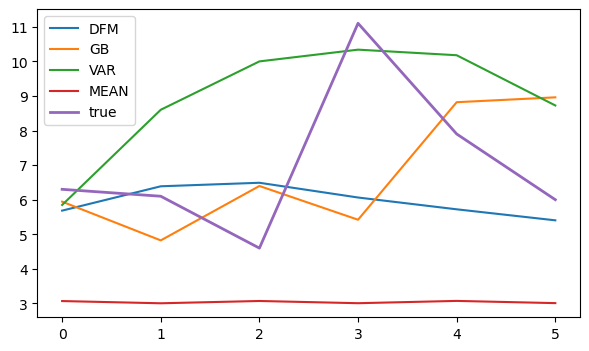

 Predicting  6 steps forward at time t= 978 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 978 DFM           : 65.56352283829304
t= 978 DFMT          : 65.56352283829304
t= 978 GB-Direct     : 58.10324646154171
t= 978 Naive Last    : 71.85927771470506
t= 978 Naive Mean    : 107.26958670849403
t= 978 VAR    : 46.71900439489654

=== nMSE RESULTS ===
t= 978 DFM           : 2.039496256616077
t= 978 DFMT          : 2.039496256616077
t= 978 GB-Direct     : 1.3012061693262502
t= 978 Naive Last    : 2.0259851559109276
t= 978 Naive Mean    : 4.329626369542559
t= 978 VAR    : 1.2207972121687558


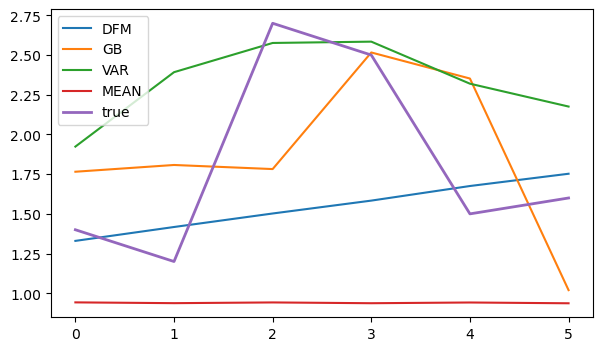

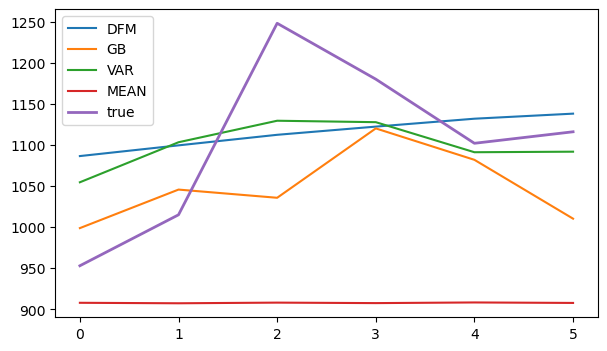

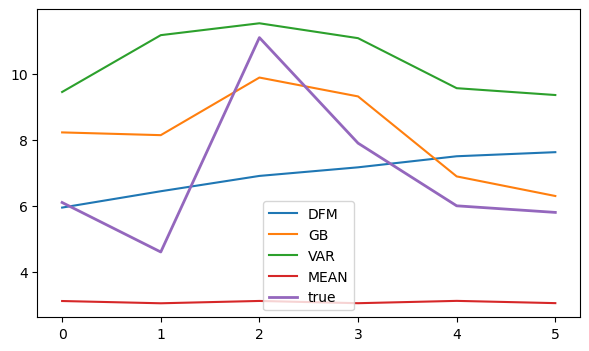

 Predicting  6 steps forward at time t= 979 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 979 DFM           : 64.80606585436166
t= 979 DFMT          : 64.80606585436166
t= 979 GB-Direct     : 60.058057659573365
t= 979 Naive Last    : 71.83964024510712
t= 979 Naive Mean    : 108.4440872309995
t= 979 VAR    : 46.85632654663169

=== nMSE RESULTS ===
t= 979 DFM           : 2.050508677767328
t= 979 DFMT          : 2.050508677767328
t= 979 GB-Direct     : 1.4878474259064736
t= 979 Naive Last    : 2.167928156125808
t= 979 Naive Mean    : 4.631837974450253
t= 979 VAR    : 1.2409707553876237


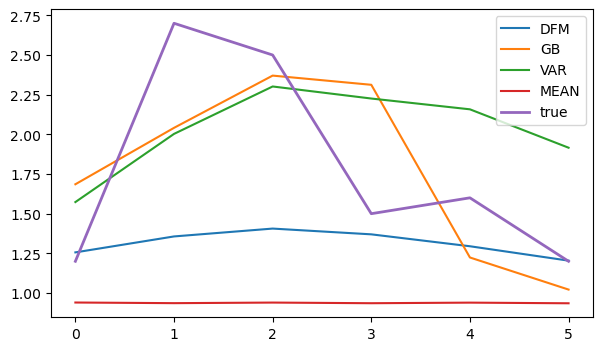

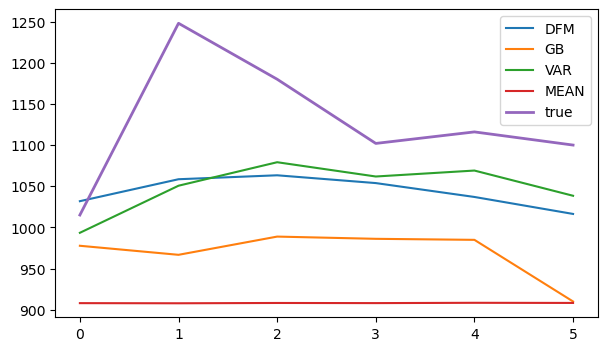

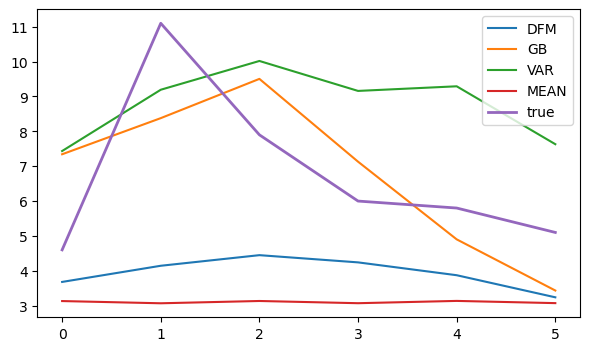

 Predicting  6 steps forward at time t= 980 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 980 DFM           : 63.99337622578893
t= 980 DFMT          : 63.99337622578893
t= 980 GB-Direct     : 63.14816103131866
t= 980 Naive Last    : 71.11607924563543
t= 980 Naive Mean    : 108.93644574360296
t= 980 VAR    : 47.128554808807024

=== nMSE RESULTS ===
t= 980 DFM           : 1.995999402629991
t= 980 DFMT          : 1.995999402629991
t= 980 GB-Direct     : 1.6665339122455152
t= 980 Naive Last    : 2.1484750627709928
t= 980 Naive Mean    : 4.673080107603088
t= 980 VAR    : 1.1872588524124603


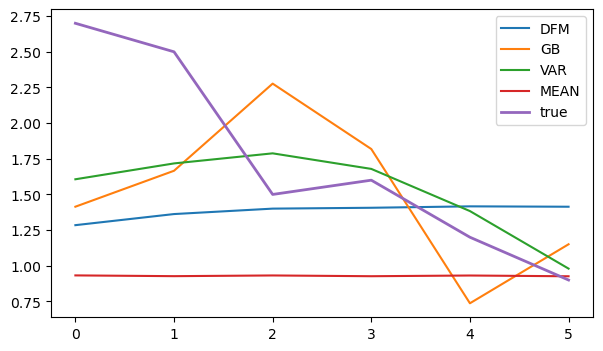

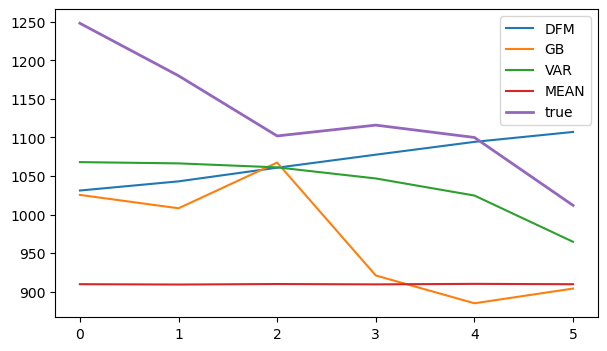

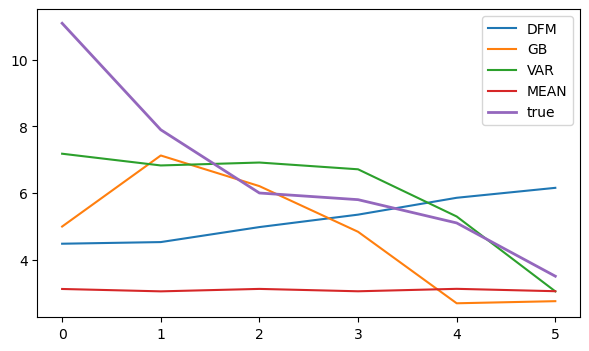

 Predicting  6 steps forward at time t= 981 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 981 DFM           : 60.96869876527592
t= 981 DFMT          : 60.96869876527592
t= 981 GB-Direct     : 63.20237103569983
t= 981 Naive Last    : 79.06299082781156
t= 981 Naive Mean    : 104.39386841195157
t= 981 VAR    : 47.58613576069629

=== nMSE RESULTS ===
t= 981 DFM           : 1.870199537869578
t= 981 DFMT          : 1.870199537869578
t= 981 GB-Direct     : 1.8680668560063438
t= 981 Naive Last    : 3.0542462065109084
t= 981 Naive Mean    : 4.349627170417628
t= 981 VAR    : 1.3396023633322527


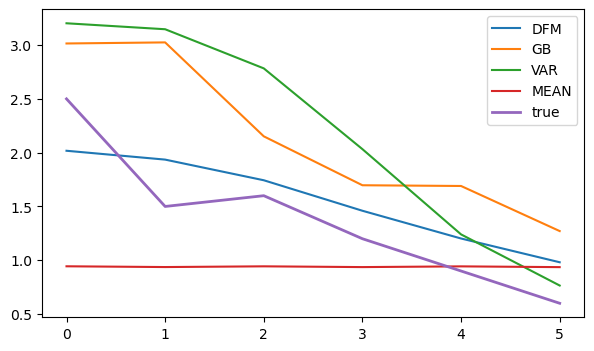

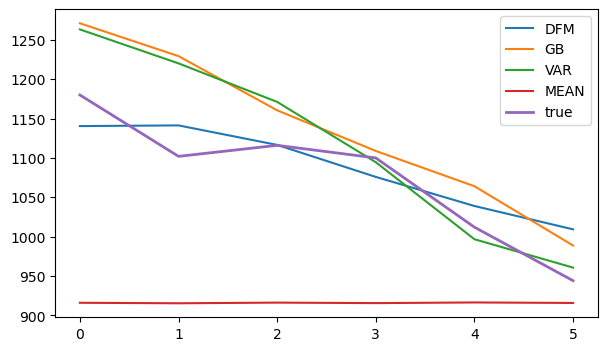

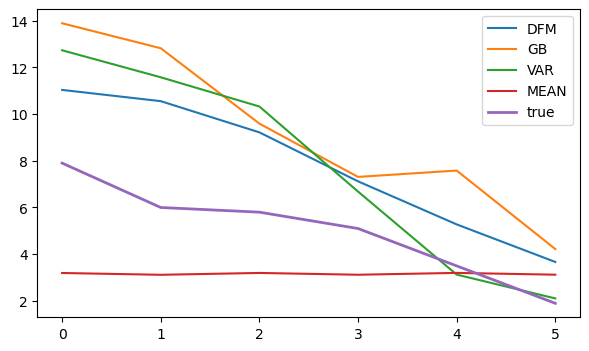

 Predicting  6 steps forward at time t= 982 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 982 DFM           : 59.54441181341283
t= 982 DFMT          : 59.54441181341283
t= 982 GB-Direct     : 59.46370029381973
t= 982 Naive Last    : 81.99484144129987
t= 982 Naive Mean    : 98.48001881463968
t= 982 VAR    : 43.897570542764576

=== nMSE RESULTS ===
t= 982 DFM           : 1.7848467510759232
t= 982 DFMT          : 1.7848467510759232
t= 982 GB-Direct     : 1.8267659999287607
t= 982 Naive Last    : 3.6085340666067762
t= 982 Naive Mean    : 3.9486882269078083
t= 982 VAR    : 1.201093433712217


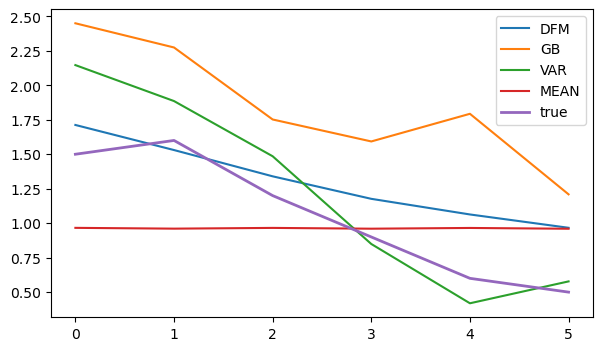

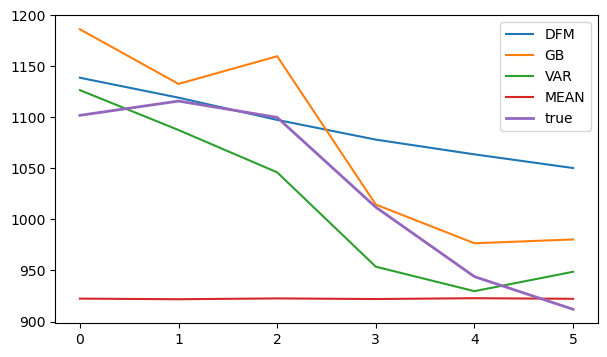

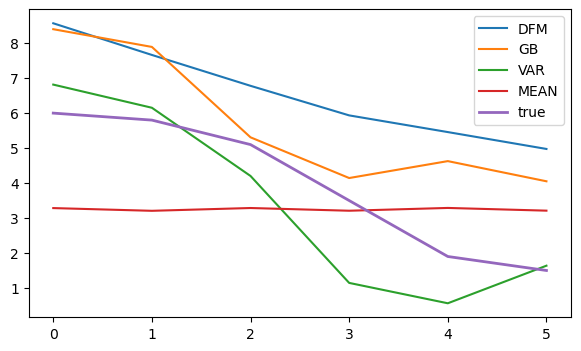

 Predicting  6 steps forward at time t= 983 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 983 DFM           : 59.36655286561607
t= 983 DFMT          : 59.36655286561607
t= 983 GB-Direct     : 56.56309004714399
t= 983 Naive Last    : 82.39327775806075
t= 983 Naive Mean    : 93.22874564384303
t= 983 VAR    : 43.35632671377869

=== nMSE RESULTS ===
t= 983 DFM           : 1.7211678040795746
t= 983 DFMT          : 1.7211678040795746
t= 983 GB-Direct     : 1.6928583259274823
t= 983 Naive Last    : 3.5397991750211504
t= 983 Naive Mean    : 3.600374560153142
t= 983 VAR    : 1.1268461896135444


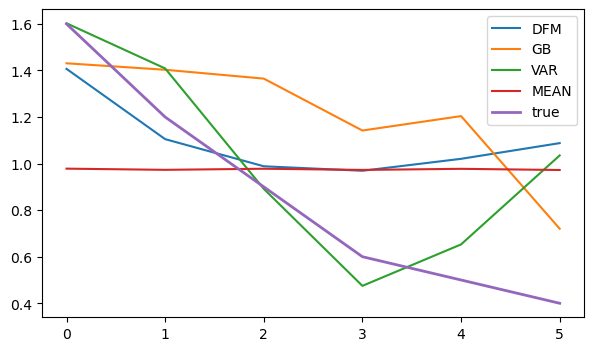

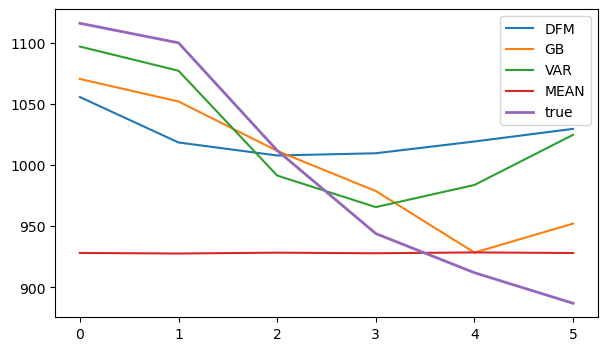

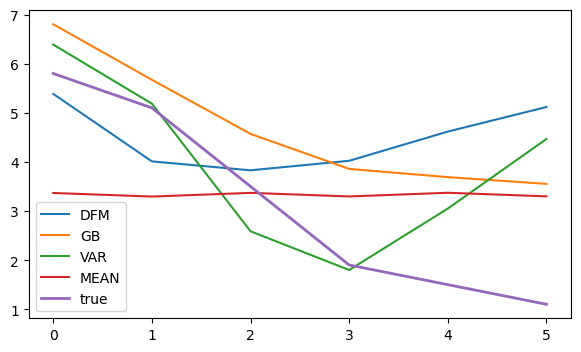

 Predicting  6 steps forward at time t= 984 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 984 DFM           : 59.75482983113555
t= 984 DFMT          : 59.75482983113555
t= 984 GB-Direct     : 55.069744058867656
t= 984 Naive Last    : 84.90577291076335
t= 984 Naive Mean    : 88.68392889938372
t= 984 VAR    : 44.57864058784663

=== nMSE RESULTS ===
t= 984 DFM           : 1.7968687835201385
t= 984 DFMT          : 1.7968687835201385
t= 984 GB-Direct     : 1.6458311497375322
t= 984 Naive Last    : 3.9232895319601124
t= 984 Naive Mean    : 3.3748450587739365
t= 984 VAR    : 1.1712135222706317


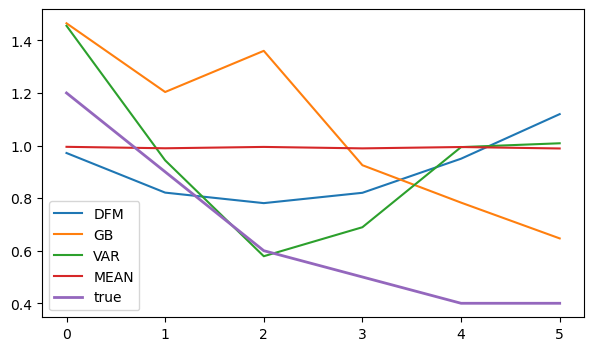

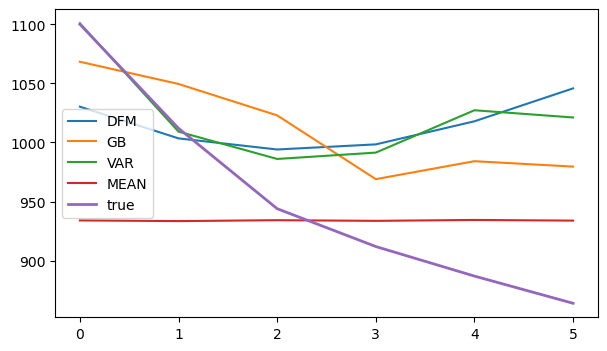

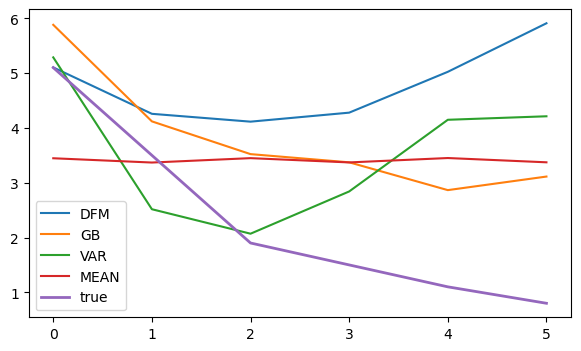

 Predicting  6 steps forward at time t= 985 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 985 DFM           : 63.101987929330846
t= 985 DFMT          : 63.101987929330846
t= 985 GB-Direct     : 54.74929672667986
t= 985 Naive Last    : 86.84284388561522
t= 985 Naive Mean    : 84.47031620602836
t= 985 VAR    : 47.5366221765822

=== nMSE RESULTS ===
t= 985 DFM           : 2.8298328225858898
t= 985 DFMT          : 2.8298328225858898
t= 985 GB-Direct     : 1.9450887377500237
t= 985 Naive Last    : 4.990617835280215
t= 985 Naive Mean    : 3.4906146819772284
t= 985 VAR    : 1.8479529763707236


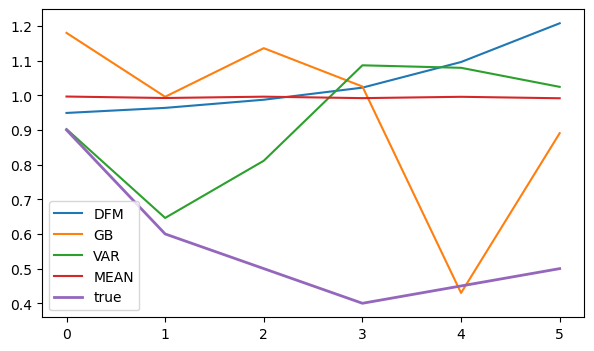

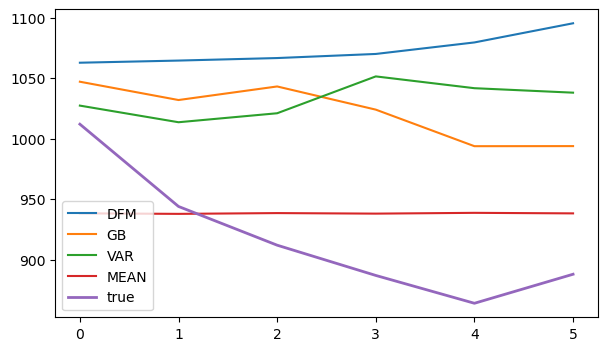

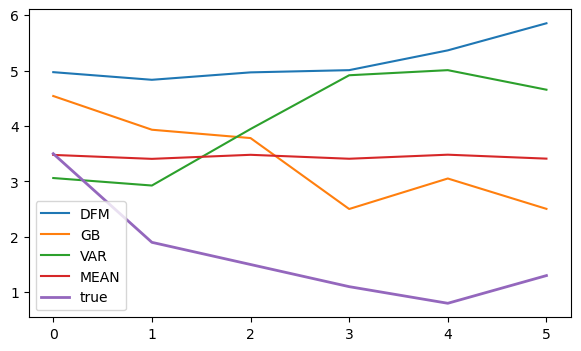

 Predicting  6 steps forward at time t= 986 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 986 DFM           : 64.66293706671615
t= 986 DFMT          : 64.66293706671615
t= 986 GB-Direct     : 53.70572955809876
t= 986 Naive Last    : 84.77303616721507
t= 986 Naive Mean    : 81.14953471940063
t= 986 VAR    : 49.326154109004804

=== nMSE RESULTS ===
t= 986 DFM           : 3.039304033487365
t= 986 DFMT          : 3.039304033487365
t= 986 GB-Direct     : 1.9239394734828144
t= 986 Naive Last    : 4.828266483204462
t= 986 Naive Mean    : 3.4046714586171287
t= 986 VAR    : 2.040718174654646


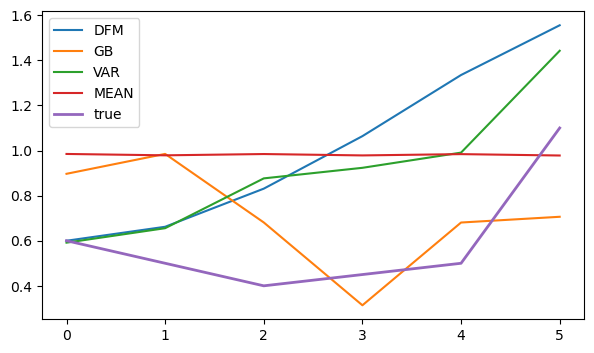

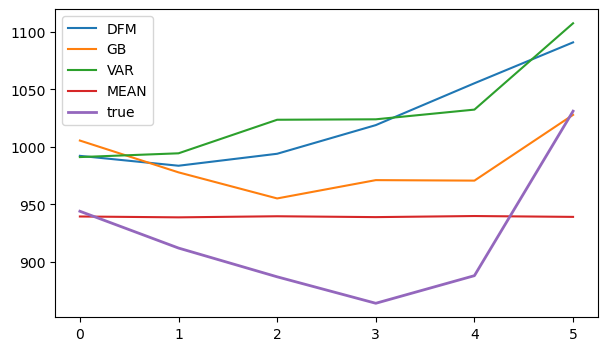

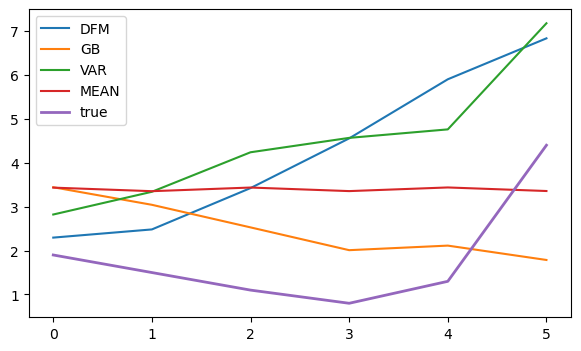

 Predicting  6 steps forward at time t= 987 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 987 DFM           : 64.21902202282466
t= 987 DFMT          : 64.21902202282466
t= 987 GB-Direct     : 56.67865322299854
t= 987 Naive Last    : 87.55371315873356
t= 987 Naive Mean    : 83.92079247930387
t= 987 VAR    : 51.86177748402696

=== nMSE RESULTS ===
t= 987 DFM           : 2.8122331716969255
t= 987 DFMT          : 2.8122331716969255
t= 987 GB-Direct     : 1.8233274242222635
t= 987 Naive Last    : 4.521213308715667
t= 987 Naive Mean    : 3.207206218967493
t= 987 VAR    : 1.9157849722146498


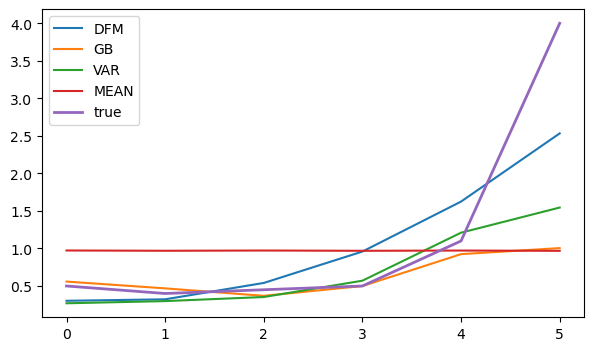

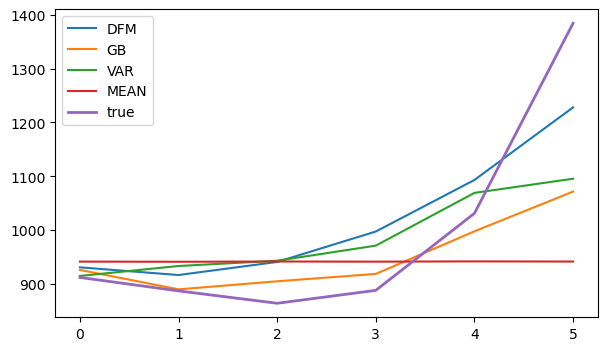

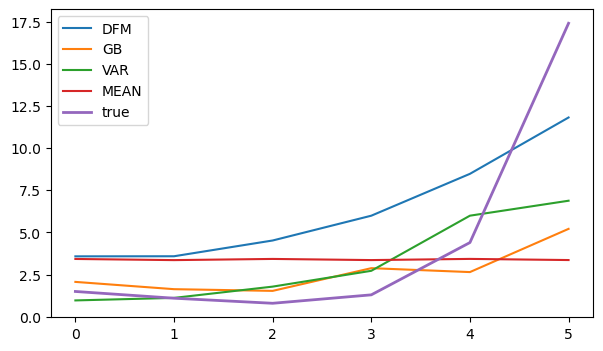

 Predicting  6 steps forward at time t= 988 


Training DFM model...


Training DFM2 model...


Training GB model...


Training VAR model...


=== RMSE RESULTS ===
t= 988 DFM           : 71.54901310784994
t= 988 DFMT          : 71.54901310784994
t= 988 GB-Direct     : 61.936537549691636
t= 988 Naive Last    : 95.23687405135561
t= 988 Naive Mean    : 90.42594377234953
t= 988 VAR    : 57.434606465758435

=== nMSE RESULTS ===
t= 988 DFM           : 2.686208421744345
t= 988 DFMT          : 2.686208421744345
t= 988 GB-Direct     : 1.743056203649048
t= 988 Naive Last    : 4.2914505841643225
t= 988 Naive Mean    : 3.056989658645929
t= 988 VAR    : 1.825326336142101


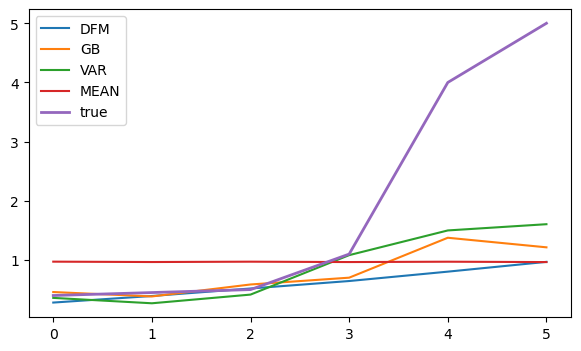

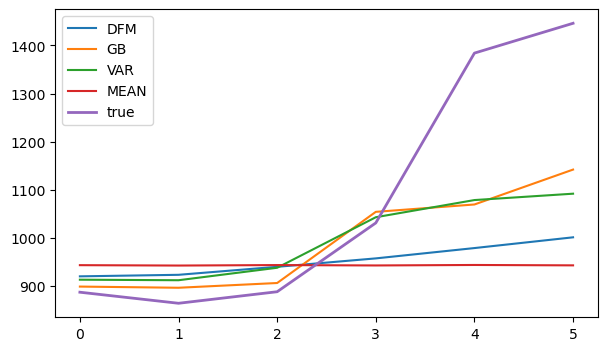

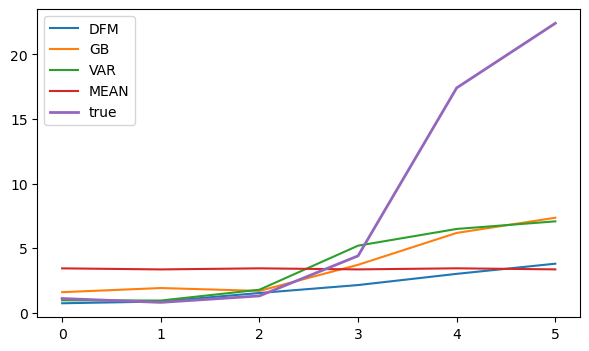

 Predicting  6 steps forward at time t= 989 


Training DFM model...



KeyboardInterrupt: 

In [122]:
import os; 
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_q_f2jjMTg9Sh65javDnxF80CVjixdrH_mOsAcvNW9Tg"

nvars=4
H = 6
window=12
nepochs=500
hidden=24
aErr=[]
aErr2=[]
aErr3=[]
aErr4=[]
aErr5=[]
aErr6=[]
aNErr=[]
aNErr2=[]
aNErr3=[]
aNErr4=[]
aNErr5=[]
aNErr6=[]
orig_df=tsdf.iloc[-1000:,:]
for starting_t in range(orig_df.shape[0]-4*H,orig_df.shape[0]-H):
    print(" Predicting " , H, "steps forward at time t=", starting_t, "\n")
    ts_train = pipeline.fit_transform(orig_df.iloc[:starting_t,:nvars]).to_numpy()
    true_future = orig_df.iloc[starting_t:(starting_t+H),:nvars]


    # ---------- Run DFM ----------
    print("\nTraining DFM model...\n")
    dfm_pred = dfm_forecast(
        ts_train,
        H=H,
        window=window,
        factors=3,
        hidden=hidden,
        epochs=nepochs,
        lr=1e-3,
        val_split=0.2,
        plot_training=False,
        transformer=False,
        verbose=False
        )
    print("\nTraining DFM2 model...\n")
    if False:
        dfm_transf = dfm_forecast(
          ts_train,
          H=H,
          window=window,
          factors=3,
          hidden=hidden,
          epochs=nepochs,
          lr=1e-3,
          val_split=0.2,
          plot_training=False,
          transformer=True,
          verbose=False
          )
    else:
          dfm_transf=dfm_pred

    # ---------- Baselines ----------
    last_pred = naive_last(ts_train, H)
    mean_pred = naive_mean(ts_train, H)
    print("\nTraining GB model...\n")
    gb_pred = gb_direct_forecast(ts_train, H=H, window=window)
    #gb_pred =tabpfn_direct_forecast(ts_train, H=H, window=window)
    print("\nTraining VAR model...\n")
    var_pred = var_forecast(ts_train, H=H, window=window)

    # ---------- Revert Transformation ----------
    dfm_pred=pipeline.inverse_transform(pd.DataFrame(dfm_pred)).to_numpy()
    dfm_transf=pipeline.inverse_transform(pd.DataFrame(dfm_transf)).to_numpy()
    gb_pred=pipeline.inverse_transform(pd.DataFrame(gb_pred)).to_numpy()
    var_pred=pipeline.inverse_transform(pd.DataFrame(var_pred)).to_numpy()
    mean_pred=pipeline.inverse_transform(pd.DataFrame(mean_pred)).to_numpy()
    last_pred=pipeline.inverse_transform(pd.DataFrame(last_pred)).to_numpy()


    true_futureN=true_future.interpolate(method="time", limit_direction="both").to_numpy()

    aErr.append(rmse(true_futureN, dfm_pred))
    aErr2.append(rmse(true_futureN, dfm_transf))
    aErr3.append(rmse(true_futureN, gb_pred))
    aErr4.append(rmse(true_futureN, last_pred))
    aErr5.append(rmse(true_futureN, mean_pred))
    aErr6.append(rmse(true_futureN, var_pred))

    aNErr.append(nmse(true_futureN, dfm_pred))
    aNErr2.append(nmse(true_futureN, dfm_transf))
    aNErr3.append(nmse(true_futureN, gb_pred))
    aNErr4.append(nmse(true_futureN, last_pred))
    aNErr5.append(nmse(true_futureN, mean_pred))
    aNErr6.append(nmse(true_futureN, var_pred))

    # ---------- RMSE ----------
    print("\n=== RMSE RESULTS ===")
    print("t=", starting_t, "DFM           :",   np.mean(aErr))
    print("t=", starting_t, "DFMT          :", np.mean(aErr2))
    print("t=", starting_t,"GB-Direct     :", np.mean(aErr3))
    print("t=", starting_t,"Naive Last    :", np.mean(aErr4))
    print("t=", starting_t,"Naive Mean    :", np.mean(aErr5))
    print("t=", starting_t,"VAR    :", np.mean(aErr6))

    # ---------- RMSE ----------
    print("\n=== nMSE RESULTS ===")
    print("t=", starting_t, "DFM           :",   np.mean(aNErr))
    print("t=", starting_t, "DFMT          :", np.mean(aNErr2))
    print("t=", starting_t,"GB-Direct     :", np.mean(aNErr3))
    print("t=", starting_t,"Naive Last    :", np.mean(aNErr4))
    print("t=", starting_t,"Naive Mean    :", np.mean(aNErr5))
    print("t=", starting_t,"VAR    :", np.mean(aNErr6))

    for nvis in range(3):
      plt.figure(figsize=(7,4))
      plt.plot(dfm_pred[:,nvis],label="DFM")
      plt.plot(gb_pred[:,nvis],label="GB")
      plt.plot(var_pred[:,nvis],label="VAR")
      plt.plot(mean_pred[:,nvis],label="MEAN")
      plt.plot(true_futureN[:,nvis],linewidth=2,label="true")
      plt.legend()

    plt.show()



In [ ]:
true_future.interpolate(method="time", limit_direction="both").to_numpy()